# Clasificación de tickets de soporte con Transformers desde cero:

Grupo: Julián Espinosa, Jhon Jairo Cuervo y David Crespo.

## Qué cambia respecto al notebook guía

- **Dominio y datos:** en vez de clasificación temática de noticias (`mteb/spanish_news`), abordamos **clasificación de tickets/quejas de atención al cliente en español** (`Faramir/Bitext-customer-support-llm-chatbot-training-dataset-spanish`, aprox 24.000 consultas reales de soporte, agrupadas en 11 categorías: cuenta, pago, pedido, reembolso, contacto, entrega, suscripción, feedback, factura, cancelación y envío).
- **Arquitectura corregida:** implementamos una versión corregida del bloque Transformer (con conexiones residuales canónicas), la apilamos en un encoder de varios bloques, y reemplazamos el clasificador basado en `Flatten` (que ata el modelo al largo máximo de secuencia) por un *pooling* enmascarado sobre la salida del encoder.
- **Comparación:** entrenamos y comparamos cuatro variantes sobre el mismo dataset y el mismo split: (1) una réplica fiel de la arquitectura de la guía como línea base, (2) la versión corregida con un solo bloque, (3) la versión corregida apilando varios bloques, y (4) la versión apilada usando la codificación posicional aprendida en vez de la sinusoidal, para ver si corregir los bugs y aumentar la profundidad realmente ayuda.


## 0. Preparación del entorno

In [ ]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Corriendo en Colab: {IN_COLAB}")


Corriendo en Colab: True


In [ ]:
!pip install -q -U datasets transformers tokenizers wordcloud scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.8 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")


Dispositivo: cpu


Para este ejercicio, definimos **desde el inicio** una configuración que se ajusta automáticamente según el dispositivo: menos épocas, un submuestreo del set de entrenamiento y capas más pequeñas si estamos en CPU. El resto de decisiones (longitud máxima de secuencia, tamaño del vocabulario) las vamos a tomar con base en el EDA.

In [ ]:
CONFIG = {
    'num_epochs': 12 if DEVICE.type == 'cuda' else 5,
    'train_subset_size': None if DEVICE.type == 'cuda' else 9000,
    'batch_size': 32 if DEVICE.type == 'cuda' else 16,
    'emb_dim': 128,
    'num_heads': 8,
    'num_blocks_stacked': 3,
    'ffn_hidden': 256 if DEVICE.type == 'cuda' else 128,
    'patience': 3,
    'bpe_vocab_size': 8000,
}
print(CONFIG)


{'num_epochs': 5, 'train_subset_size': 9000, 'batch_size': 16, 'emb_dim': 128, 'num_heads': 8, 'num_blocks_stacked': 3, 'ffn_hidden': 128, 'patience': 3, 'bpe_vocab_size': 8000}


## 1. Cargando el dataset

Usamos [`Faramir/Bitext-customer-support-llm-chatbot-training-dataset-spanish`](https://huggingface.co/datasets/Faramir/Bitext-customer-support-llm-chatbot-training-dataset-spanish), una versión en español de un dataset de Bitext con consultas reales de atención al cliente. Cada fila trae, entre otras columnas, el texto de la consulta (`instruction`), una categoría gruesa (`category`, 11 clases) y una intención más fina (`intent`, 27 clases). Nosotros vamos a predecir `category`.

In [ ]:
from datasets import load_dataset

DATASET_NAME = "Faramir/Bitext-customer-support-llm-chatbot-training-dataset-spanish"

try:
    raw_dataset = load_dataset(DATASET_NAME, split="train")
except Exception as e:
    print(f"Carga por defecto falló ({e}); reintentando con la rama de parquet convertido...")
    raw_dataset = load_dataset(DATASET_NAME, revision="refs/convert/parquet", split="train")

print(raw_dataset)


README.md:   0%|          | 0.00/2.52k [00:00<?, ?B/s]

bitext_customer_support_es_train.jsonl: reconstructing file:   0%|          |  0.00B / 18.2MB            

bitext_customer_support_es_train.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/24184 [00:00<?, ? examples/s]

Dataset({
    features: ['flags', 'instruction', 'category', 'intent', 'response'],
    num_rows: 24184
})


In [ ]:
raw_dataset[0]


{'flags': 'BILPQ',
 'instruction': 'Podría ayudarme a cerrar una cuenta freemium',
 'category': 'ACCOUNT',
 'intent': 'delete_account',
 'response': 'Gracias por su mensaje a nosotros para ayudarle a cerrar su cuenta {{Account Category}}. Entiendo que está buscando cerrar su cuenta y estoy aquí para guiarle a través del proceso. Para cancelar su cuenta {{Account Category}}, por favor siga los pasos descritos en nuestro sitio web o póngase en contacto con nuestro equipo de soporte al cliente que estará encantado de ayudarle con el cierre de la cuenta.'}

## 2. Análisis exploratorio (EDA)

In [ ]:
import pandas as pd

df = raw_dataset.to_pandas()
df = df[['instruction', 'category', 'intent']].copy()
df['instruction'] = df['instruction'].astype(str).str.strip()
df = df[df['instruction'].str.len() > 0].reset_index(drop=True)

print(f"Total de tickets: {len(df)}")
df.head()


Total de tickets: 24184


,instruction,category,intent
0,Podría ayudarme a cerrar una cuenta freemium,ACCOUNT,delete_account
1,No sé qué debo hacer para informar de los prob...,PAYMENT,payment_issue
2,Quiero ver a qué hora puedo llamar al servicio...,CONTACT,contact_customer_service
3,Necesito ver en qué casos puedo solicitar un r...,REFUND,check_refund_policy
4,La apertura de una nueva cuenta freemium,ACCOUNT,create_account


### Distribución por categoría

Este va a ser nuestro objetivo de clasificación. Revisamos qué tan balanceadas están las 11 categorías.

category
ACCOUNT         5397
ORDER           3586
REFUND          2689
DELIVERY        1799
PAYMENT         1796
INVOICE         1795
FEEDBACK        1795
CONTACT         1785
SHIPPING        1783
SUBSCRIPTION     894
CANCEL           865
Name: count, dtype: int64


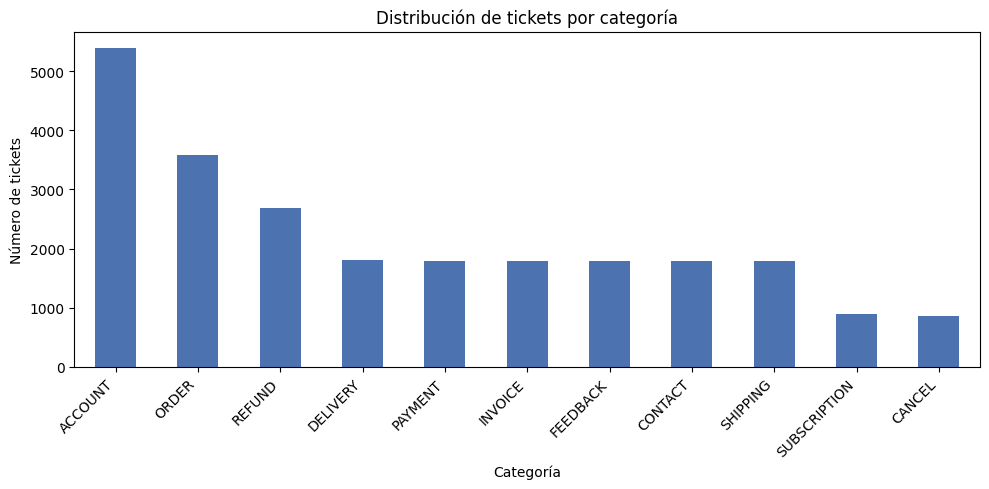

Razón entre la categoría más y menos frecuente: 6.24x


In [ ]:
import matplotlib.pyplot as plt

category_counts = df['category'].value_counts().sort_values(ascending=False)
print(category_counts)

plt.figure(figsize=(10, 5))
category_counts.plot(kind='bar', color='#4C72B0')
plt.title('Distribución de tickets por categoría')
plt.ylabel('Número de tickets')
plt.xlabel('Categoría')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ratio_desbalance = category_counts.max() / category_counts.min()
print(f"Razón entre la categoría más y menos frecuente: {ratio_desbalance:.2f}x")


### Distribución por intent (contexto)

El dataset trae una segunda etiqueta más fina, `intent` (27 clases dentro de las 11 categorías).

Número de intents distintos: 27


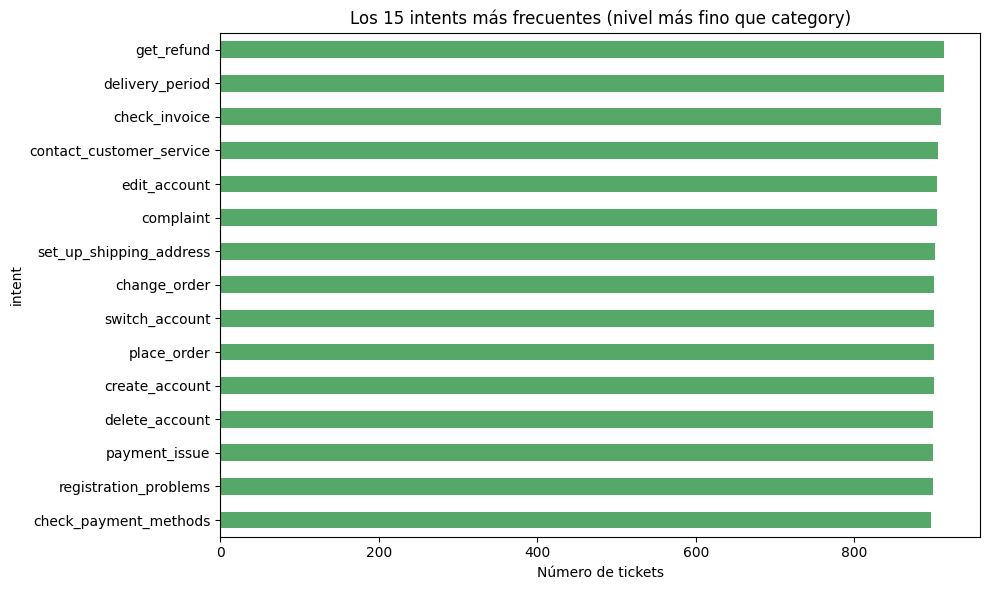

In [ ]:
intent_counts = df['intent'].value_counts()
print(f"Número de intents distintos: {df['intent'].nunique()}")

plt.figure(figsize=(10, 6))
intent_counts.head(15).plot(kind='barh', color='#55A868')
plt.title('Los 15 intents más frecuentes (nivel más fino que category)')
plt.xlabel('Número de tickets')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Longitud de los textos

 Nuestros textos son consultas cortas de soporte, así que esperamos poder usar una longitud máxima mucho menor que la del taller guía.

          num_chars     num_words
count  24184.000000  24184.000000
mean      52.515878      8.424868
std       16.113684      2.642236
min       11.000000      2.000000
25%       44.000000      7.000000
50%       53.000000      8.000000
75%       60.000000     10.000000
max      710.000000    112.000000


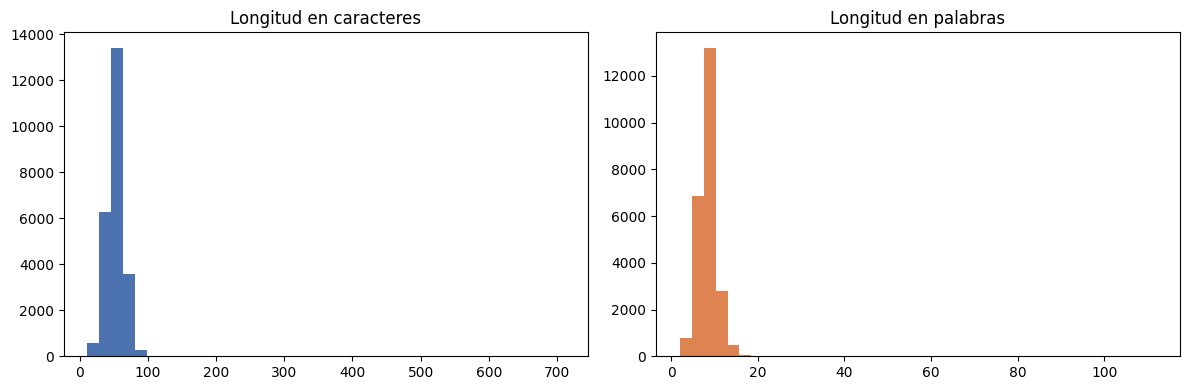

Percentil 95 de longitud en palabras: 12


In [ ]:
df['num_chars'] = df['instruction'].str.len()
df['num_words'] = df['instruction'].str.split().apply(len)

print(df[['num_chars', 'num_words']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['num_chars'], bins=40, color='#4C72B0')
axes[0].set_title('Longitud en caracteres')
axes[1].hist(df['num_words'], bins=40, color='#DD8452')
axes[1].set_title('Longitud en palabras')
plt.tight_layout()
plt.show()

p95_words = int(np.percentile(df['num_words'], 95))
print(f"Percentil 95 de longitud en palabras: {p95_words}")


In [ ]:
CONFIG['max_len'] = int(np.clip(p95_words + 4, 24, 64))
print(f"max_len elegido (data-driven, con margen sobre el percentil 95): {CONFIG['max_len']}")


max_len elegido (data-driven, con margen sobre el percentil 95): 24


### Ejemplos por categoría

In [ ]:
for cat in sorted(df['category'].unique()):
    ejemplo = df[df['category'] == cat]['instruction'].iloc[0]
    print(f"[{cat}] {ejemplo}")


[ACCOUNT] Podría ayudarme a cerrar una cuenta freemium
[CANCEL] Necesito ayuda para ver las tarifas de salida anticipada
[CONTACT] Quiero ver a qué hora puedo llamar al servicio al cliente.
[DELIVERY] Quiero saber más sobre el período de envío
[FEEDBACK] ¿Cómo presentar un reclamo contra su empresa?
[INVOICE] comprobar las facturas de {{Person Name}}
[ORDER] ¿Cómo podría añadir algunos malditos productos para ordenar {{Order Number}}?
[PAYMENT] No sé qué debo hacer para informar de los problemas de pago.
[REFUND] Necesito ver en qué casos puedo solicitar un reembolso, ayúdame.
[SHIPPING] ¿Puedes ayudarme a enviar una dirección de entrega diferente?
[SUBSCRIPTION] Tengo que suscribirme a su boletín informativo corporativo.


### Nubes de palabras

Miramos las tres categorías más frecuentes para ver qué tanto se solapa el vocabulario.

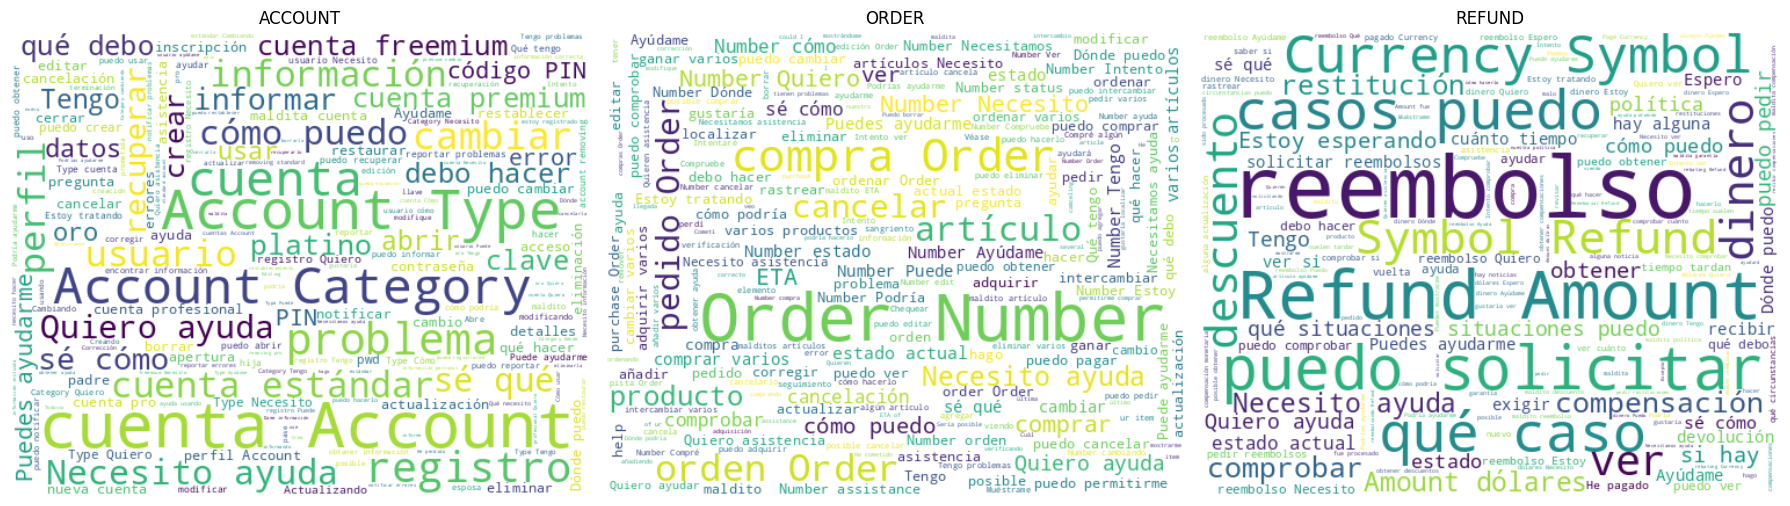

In [ ]:
from wordcloud import WordCloud

stopwords_texto = (
    "a al algo algunas algunos ante antes como con contra cual cuando de del desde donde "
    "durante e el ella ellas ellos en entre era erais eramos eran eras eres es esa esas ese eso esos esta estas "
    "este esto estos ha hace hacia hasta la las le les lo los mas me mi mientras muy nada ni no nos nosotras "
    "nosotros o os otra otras otro otros para pero poco por porque que quien quienes se sin sobre su sus te tu "
    "tus un una uno unos y ya yo mis del al"
)
STOPWORDS_ES = set(stopwords_texto.split())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
categorias_muestra = category_counts.index[:3]
for ax, cat in zip(axes, categorias_muestra):
    texto = ' '.join(df[df['category'] == cat]['instruction'].tolist())
    wc = WordCloud(width=500, height=400, background_color='white', stopwords=STOPWORDS_ES).generate(texto)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat)
    ax.axis('off')
plt.tight_layout()
plt.show()


La categoría más frecuente es ACCOUNT con 5397 tickets, y las menos frecuentes son CANCEL con 865 y SUBSCRIPTION con 894, lo que da una razón de desbalance de 6.24 veces entre la categoría más grande y la más chica. No es un desbalance extremo, pero sí alcanza para justificar el uso de pesos de clase al entrenar, que es lo que hicimos más adelante.

En las nubes de palabras se ve bastante solapamiento de vocabulario entre categorías, sobre todo palabras genéricas de atención al cliente como cuenta, ayuda o poder, que aparecen en varias categorías a la vez. El vocabulario que sí distingue con claridad cada categoría, como reembolso, factura, envío o cancelar, aparece con menos frecuencia dentro de cada nube porque los tickets son cortos.

En cuanto a la longitud, el promedio es de apenas 8.4 palabras por ticket (52.5 caracteres), con un máximo de 112 palabras. Eso está muy lejos de la longitud de un artículo de noticias completo como los que usa la guía, que necesitan hasta 2048 tokens. Por eso pudimos usar una longitud máxima de secuencia de solo 24 tokens sin perder información en la gran mayoría de los casos: el percentil 95 de longitud en palabras fue de 12.

## 3. Tokenización

Entrenamos nuestro propio tokenizador BPE (a partir del vocabulario base de GPT-2) en vez de usar uno preentrenado, para que se ajuste al vocabulario específico de nuestro dominio. La diferencia es el tamaño del vocabulario: la guía usa 50.000 tokens porque entrena sobre un corpus de noticias con vocabulario amplio y variado; nuestro corpus de tickets de soporte es mucho más acotado en temática y en longitud, así que usamos un vocabulario más pequeño (8.000 tokens), lo cual también ayuda a mantener la tabla de embeddings liviana para CPU.

In [ ]:
from tqdm.auto import tqdm
from tokenizers.pre_tokenizers import ByteLevel
from transformers import AutoTokenizer

base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
base_vocab = list(ByteLevel.alphabet())

textos_entrenamiento = df['instruction'].tolist()

def batch_iterator(batch_size=64):
    for i in tqdm(range(0, len(textos_entrenamiento), batch_size)):
        yield textos_entrenamiento[i:i + batch_size]

tickets_tokenizer = base_tokenizer.train_new_from_iterator(
    batch_iterator(),
    vocab_size=CONFIG['bpe_vocab_size'],
    initial_alphabet=base_vocab,
    show_progress=True,
    new_special_tokens=["[PAD]"],
)

if tickets_tokenizer.pad_token is None:
    tickets_tokenizer.pad_token = '[PAD]'

VOCAB_SIZE = len(tickets_tokenizer)
print(f"Tamaño del vocabulario: {VOCAB_SIZE}")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

  0%|          | 0/378 [00:00<?, ?it/s]

Tamaño del vocabulario: 5250


In [ ]:
sample = df['instruction'].iloc[0]
encoded = tickets_tokenizer(sample, max_length=CONFIG['max_len'], truncation=True, padding='max_length')

print(sample)
print(encoded['input_ids'][:20])
print(tickets_tokenizer.convert_ids_to_tokens(encoded['input_ids'])[:20])


Podría ayudarme a cerrar una cuenta freemium
[690, 419, 264, 1004, 344, 329, 798, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
['PodrÃŃa', 'Ġayudarme', 'Ġa', 'Ġcerrar', 'Ġuna', 'Ġcuenta', 'Ġfreemium', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 4. Dataset y DataLoaders

Definimos una clase `Dataset` análoga a la `SpanishNewsDataset` de la guía, adaptada a nuestras columnas (`instruction` como texto, `category` como etiqueta).

In [ ]:
import torch
from torch.utils.data import Dataset

class TicketsDataset(Dataset):

    def __init__(self, tokenizer, texts, labels, seq_length):
        self.tokenizer = tokenizer
        self.texts = texts
        self.labels = labels
        self.seq_length = seq_length
        self.classes = sorted(set(labels))
        self.class_to_id = {c: i for i, c in enumerate(self.classes)}
        self.id_to_class = {i: c for c, i in self.class_to_id.items()}
        self.num_classes = len(self.classes)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        y = self.class_to_id[self.labels[idx]]
        enc = self.tokenizer(
            text,
            max_length=self.seq_length,
            truncation=True,
            padding='max_length',
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item['y'] = torch.tensor(y)
        return item


In [ ]:
full_dataset = TicketsDataset(
    tickets_tokenizer,
    texts=df['instruction'].tolist(),
    labels=df['category'].tolist(),
    seq_length=CONFIG['max_len'],
)

NUM_CLASSES = full_dataset.num_classes
ID_TO_CLASS = full_dataset.id_to_class
CLASS_TO_ID = full_dataset.class_to_id

print(f"Clases: {full_dataset.classes}")
print(f"Número de clases: {NUM_CLASSES}")


Clases: ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']
Número de clases: 11


Si estamos en CPU, tomamos un submuestreo aleatorio (pero reproducible) del dataset completo para que entrenar los cuatro modelos sea viable en un tiempo razonable.

In [ ]:
from torch.utils.data import Subset, random_split, DataLoader

all_idx = list(range(len(full_dataset)))
if CONFIG['train_subset_size'] is not None and CONFIG['train_subset_size'] < len(full_dataset):
    random.Random(SEED).shuffle(all_idx)
    used_idx = all_idx[:CONFIG['train_subset_size']]
    print(f"Modo CPU: usando un subconjunto de {len(used_idx)} tickets de {len(full_dataset)} para acelerar el entrenamiento")
else:
    used_idx = all_idx
    print(f"Usando el dataset completo: {len(used_idx)} tickets")

dataset_used = Subset(full_dataset, used_idx)

n_total = len(dataset_used)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    dataset_used, lengths=[n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Modo CPU: usando un subconjunto de 9000 tickets de 24184 para acelerar el entrenamiento
Train: 7200 | Val: 900 | Test: 900


## 5. Positional encodings: lo que encontramos al revisar `LearnablePE`

La guía define dos formas de codificación posicional: `SinusoidPE` (la que realmente usa en su modelo final) y `LearnablePE` (definida pero **nunca instanciada** en ningún modelo de la guía). Revisamos `SinusoidPE` y la fórmula está bien implementada —coincide con la propuesta de *Attention is All You Need*—, así que la dejamos igual.

In [ ]:
import math
import torch.nn as nn
from enum import Enum


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):
    # Igual a la propuesta original de 'Attention Is All You Need' y a la
    # implementación de la guía. Aquí no encontramos ningún error.

    def __init__(self, max_len, d_model):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        i = torch.arange(d_model).unsqueeze(0)
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        angle_rads = pos * div_term

        pos_encoding = torch.zeros(max_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):
    # Versión corregida: la tabla se dimensiona con max_len (no vocab_size) y
    # Codificación posicional aprendida: en vez de una fórmula fija, cada
# posición tiene un vector de parámetros que se ajusta durante el entrenamiento.

    def __init__(self, max_len, d_model):
        super().__init__()
        self.embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device)
        pos_emb = self.embedding(positions)
        return x + pos_emb.unsqueeze(0)


class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len, embed_dim, vocab_size, pos_encoding_type=PosEncodingType.SINUSOID):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(max_len, embed_dim)

    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)


Visualizamos ambas codificaciones antes de entrenar.

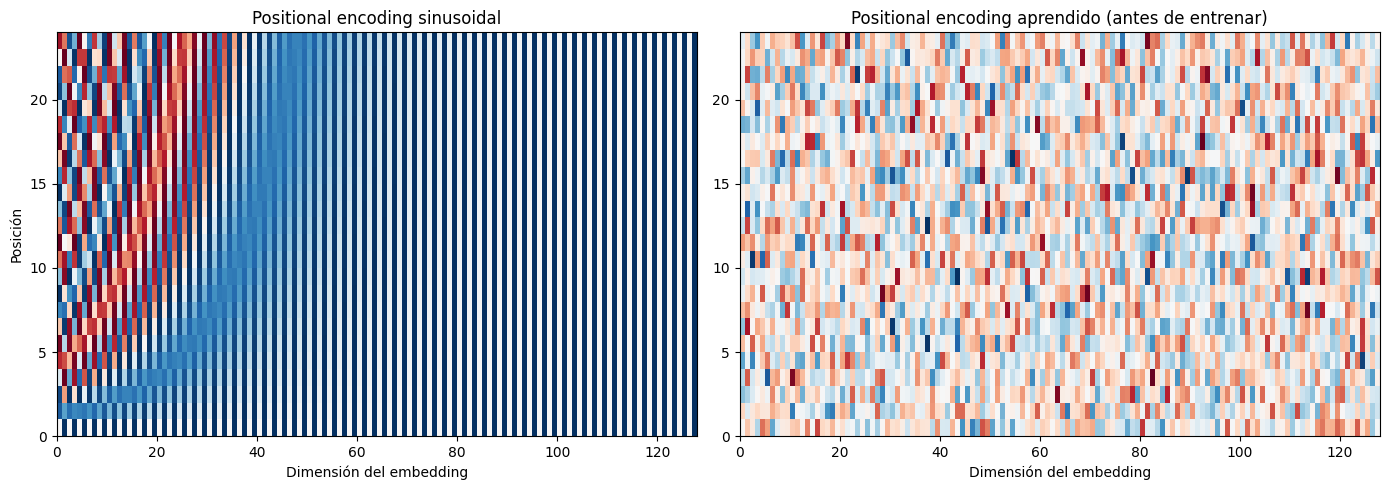

In [ ]:
tpe_sin = TokenAndPosEmbedding(CONFIG['max_len'], CONFIG['emb_dim'], VOCAB_SIZE, PosEncodingType.SINUSOID)
tpe_learn = TokenAndPosEmbedding(CONFIG['max_len'], CONFIG['emb_dim'], VOCAB_SIZE, PosEncodingType.LEARNABLE)

pe_sin = tpe_sin.pos_emb.pos_encoding.squeeze(0).numpy()
pe_learn = tpe_learn.pos_emb.embedding.weight.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pcolormesh(pe_sin, cmap='RdBu')
axes[0].set_title('Positional encoding sinusoidal')
axes[0].set_xlabel('Dimensión del embedding')
axes[0].set_ylabel('Posición')
axes[1].pcolormesh(pe_learn, cmap='RdBu')
axes[1].set_title('Positional encoding aprendido (antes de entrenar)')
axes[1].set_xlabel('Dimensión del embedding')
plt.tight_layout()
plt.show()


## 6. Multi-Head Attention y el bloque Transformer: lo que corregimos

Al revisar `MultiHeadAttention` y `TransformerBlock` de la guía encontramos varios problemas:

1. **`assert embed_size & num_heads == 0`**: usa el operador bit a bit `&` en vez del operador módulo `%` para verificar divisibilidad. Con `embed_dim=128` y `num_heads=8` el assert "pasa" por coincidencia binaria (`128 & 8 == 0`), pero no es una verificación real de divisibilidad — con otras combinaciones podría dejar pasar configuraciones inválidas o rechazar unas válidas.
2. **`masked_fill(mask == 0, -9e-15)`**: el comentario del propio notebook dice que la idea es "poner los valores de atención en números muy pequeños" para que el softmax los ignore. Pero `-9e-15` es un número **cercano a cero**, no un número negativo grande. Después del softmax esto apenas atenúa la atención sobre las posiciones de padding — para que la máscara funcione de verdad, el valor debe ser muy negativo, no muy pequeño en magnitud absoluta.
3. **`TransformerBlock.forward` nunca suma la entrada de vuelta**: la arquitectura Transformer se llama "residual" precisamente porque cada sub-capa (atención, feed-forward) se combina con su entrada antes de la normalización (`x = LayerNorm(x + Sublayer(x))`). En el código de la guía, `x = self.layer_norm1(attn_output)` y `return self.layer_norm2(ffn_out)` descartan la entrada `x` por completo. Esto no es solo un detalle: sin las conexiones residuales, apilar varios bloques (que es justo la extensión que queremos explorar) tiende a degradar el entrenamiento porque el gradiente no tiene un camino directo hacia las primeras capas.

Abajo replicamos primero la versión original (con sus bugs) para tener una línea base fiel a la guía, y luego implementamos la versión corregida.

In [ ]:
import math
import torch.nn as nn

class MultiHeadAttentionOriginal(nn.Module):
    # Réplica fiel de la implementación de la guía, con sus mismos errores,
    # para tener una línea base justa de comparación sobre nuestro propio dataset.

    def __init__(self, embed_size, num_heads=8):
        super().__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size & num_heads == 0, 'El tamaño del embedding debería ser divisible por el número de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.combine_heads = nn.Linear(embed_size, embed_size)

    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        d_k = q.size()[-1]
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        attn_logits = attn_logits / math.sqrt(d_k)
        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e-15)
        attention = torch.softmax(attn_logits, dim=-1)
        values = torch.matmul(attention, v)
        return values, attention

    def _separate_heads(self, x, batch_size):
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_len, emb_dim = x.size()
        q = self._separate_heads(self.query(x), batch_size)
        k = self._separate_heads(self.key(x), batch_size)
        v = self._separate_heads(self.value(x), batch_size)
        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3).reshape(batch_size, seq_len, emb_dim)
        output = self.combine_heads(weights)
        if return_attention:
            return output, attention
        return output


class TransformerBlockOriginal(nn.Module):
    # Réplica fiel del bloque de la guía: sin conexiones residuales.

    def __init__(self, emb_dim, num_heads=8, ffn_hidden=512):
        super().__init__()
        self.mhatt = MultiHeadAttentionOriginal(emb_dim, num_heads)
        self.mhatt_dropout = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, ffn_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(ffn_hidden, emb_dim),
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x, mask=None):
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropout(attn_output)
        x = self.layer_norm1(attn_output)      # sin residual, igual que la guía
        ffn_out = self.ffn(x)
        return self.layer_norm2(ffn_out)         # sin residual, igual que la guía


In [ ]:
class MultiHeadAttentionFixed(nn.Module):
    # Misma idea que la de la guía, con la validación de divisibilidad y el
    # valor de la máscara corregidos.

    def __init__(self, embed_size, num_heads=8):
        super().__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size % num_heads == 0, 'El tamaño del embedding debería ser divisible por el número de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.combine_heads = nn.Linear(embed_size, embed_size)

    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        d_k = q.size()[-1]
        attn_logits = torch.matmul(q, k.transpose(-2, -1))
        attn_logits = attn_logits / math.sqrt(d_k)
        if mask is not None:
            attn_logits = attn_logits.masked_fill(mask.reshape(mask.shape[0], 1, 1, -1) == 0, -1e9)
        attention = torch.softmax(attn_logits, dim=-1)
        values = torch.matmul(attention, v)
        return values, attention

    def _separate_heads(self, x, batch_size):
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_len, emb_dim = x.size()
        q = self._separate_heads(self.query(x), batch_size)
        k = self._separate_heads(self.key(x), batch_size)
        v = self._separate_heads(self.value(x), batch_size)
        weights, attention = self._scaled_dot_product(q, k, v, mask)
        weights = weights.permute(0, 2, 1, 3).reshape(batch_size, seq_len, emb_dim)
        output = self.combine_heads(weights)
        if return_attention:
            return output, attention
        return output


class TransformerBlockFixed(nn.Module):
    # Bloque Transformer canónico: post-layernorm con conexiones residuales
    # alrededor de la atención y de la red feed-forward (Vaswani et al., 2017).

    def __init__(self, emb_dim, num_heads=8, ffn_hidden=512):
        super().__init__()
        self.mhatt = MultiHeadAttentionFixed(emb_dim, num_heads)
        self.mhatt_dropout = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, ffn_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(ffn_hidden, emb_dim),
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x, mask=None, return_attention=False):
        attn_output, attention = self.mhatt(x, mask, return_attention=True)
        attn_output = self.mhatt_dropout(attn_output)
        x = self.layer_norm1(x + attn_output)     # residual 1
        ffn_out = self.ffn(x)
        x = self.layer_norm2(x + ffn_out)          # residual 2
        if return_attention:
            return x, attention
        return x


class StackedTransformerEncoder(nn.Module):
    # Apila N bloques TransformerBlockFixed uno tras otro. La guía solo usa
    # un bloque; aquí exploramos si apilar varios ayuda, como en el Transformer
    # original (que apila 6 bloques por defecto).

    def __init__(self, emb_dim, num_heads, num_blocks, ffn_hidden=512):
        super().__init__()
        self.blocks = nn.ModuleList([
            TransformerBlockFixed(emb_dim, num_heads, ffn_hidden) for _ in range(num_blocks)
        ])

    def forward(self, x, mask=None, return_attention=False):
        attentions = []
        for block in self.blocks:
            if return_attention:
                x, attn = block(x, mask, return_attention=True)
                attentions.append(attn)
            else:
                x = block(x, mask)
        if return_attention:
            return x, attentions
        return x


Hicimos la prueba con embed_size igual a 130 y num_heads igual a 8. 130 no es divisible por 8 (130 entre 8 da resto 2), así que el assert debería fallar. Pero 130 y 8 en operación bit a bit dan 0, así que la validación original de la guía habría dejado pasar esa configuración inválida sin ningún error, y el problema solo se habría notado más adelante, en medio del cálculo de atención, de una forma mucho más confusa de depurar. Con la corrección, usando el operador de módulo en vez del operador bit a bit, el assert sí detecta el problema apenas se intenta construir el modelo.

## 7. Del `Flatten` al pooling enmascarado

El clasificador de la guía aplana toda la secuencia (`nn.Flatten()` sobre `max_len * emb_dim`) antes de la primera capa densa. Esto tiene dos problemas: ata el tamaño del clasificador al largo máximo de secuencia (con textos largos y `emb_dim` grande, la primera capa densa puede tener millones de parámetros solo por esto), y hace que la *posición* de cada palabra en la secuencia importe para la clasificación, en lugar de resumir el *contenido* de la secuencia sin importar en qué posición aparece cada token.

En vez de eso, usamos un *pooling* de promedio enmascarado: promediamos los vectores de salida del encoder a lo largo de la secuencia, ignorando las posiciones de padding gracias a la máscara de atención. Es la misma idea detrás del *pooling* que usan modelos como BERT para obtener una representación de tamaño fijo a partir de una secuencia de longitud variable.

In [ ]:
def masked_mean_pool(x, mask):
    mask = mask.unsqueeze(-1).float()
    summed = (x * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-6)
    return summed / counts


class TicketTransformerClassifier(nn.Module):
    # Clasificador configurable: la misma clase nos sirve para instanciar la
    # réplica fiel de la guía y las variantes corregidas, cambiando solo los
    # parámetros de construcción.

    def __init__(self, max_len, vocab_size, num_classes, emb_dim, num_heads=8,
                 num_blocks=1, ffn_hidden=512, pos_encoding_type=PosEncodingType.SINUSOID,
                 use_original_block=False, use_pooling=True):
        super().__init__()
        self.use_pooling = use_pooling
        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size, pos_encoding_type)

        if use_original_block:
            self.encoder = TransformerBlockOriginal(emb_dim, num_heads, ffn_hidden)
        elif num_blocks == 1:
            self.encoder = TransformerBlockFixed(emb_dim, num_heads, ffn_hidden)
        else:
            self.encoder = StackedTransformerEncoder(emb_dim, num_heads, num_blocks, ffn_hidden)

        if use_pooling:
            self.classifier = nn.Sequential(
                nn.Linear(emb_dim, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes),
            )
        else:
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(max_len * emb_dim, 512),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(512, num_classes),
            )

    def forward(self, x, mask=None, return_attention=False):
        embeddings = self.token_embeddings(x)
        attention = None
        if return_attention and not isinstance(self.encoder, TransformerBlockOriginal):
            encoded, attention = self.encoder(embeddings, mask, return_attention=True)
        else:
            encoded = self.encoder(embeddings, mask)

        if self.use_pooling:
            pooled = masked_mean_pool(encoded, mask)
            logits = self.classifier(pooled)
        else:
            logits = self.classifier(encoded)

        if return_attention:
            return logits, attention
        return logits


### Las cuatro variantes que vamos a comparar

In [ ]:
modelos_config = {
    'Baseline (réplica fiel de la guía)': dict(
        num_blocks=1, pos_encoding_type=PosEncodingType.SINUSOID,
        use_original_block=True, use_pooling=False,
    ),
    'Corregido - 1 bloque': dict(
        num_blocks=1, pos_encoding_type=PosEncodingType.SINUSOID,
        use_original_block=False, use_pooling=True,
    ),
    'Corregido - 3 bloques (Sinusoid)': dict(
        num_blocks=CONFIG['num_blocks_stacked'], pos_encoding_type=PosEncodingType.SINUSOID,
        use_original_block=False, use_pooling=True,
    ),
    'Corregido - 3 bloques (Learnable PE)': dict(
        num_blocks=CONFIG['num_blocks_stacked'], pos_encoding_type=PosEncodingType.LEARNABLE,
        use_original_block=False, use_pooling=True,
    ),
}

def build_model(cfg):
    return TicketTransformerClassifier(
        max_len=CONFIG['max_len'],
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        emb_dim=CONFIG['emb_dim'],
        num_heads=CONFIG['num_heads'],
        ffn_hidden=CONFIG['ffn_hidden'],
        **cfg,
    )

for nombre, cfg in modelos_config.items():
    m = build_model(cfg)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{nombre}: {n_params:,} parámetros")


Baseline (réplica fiel de la guía): 2,350,603 parámetros
Corregido - 1 bloque: 807,435 parámetros
Corregido - 3 bloques (Sinusoid): 1,006,603 parámetros
Corregido - 3 bloques (Learnable PE): 1,009,675 parámetros


## 8. Entrenamiento

La guía entrena con PyTorch Lightning. Nosotros usamos un bucle de entrenamiento manual porque nos da control directo sobre el *early stopping*, el *clipping* de gradientes y el registro de métricas por época, sin depender de otro framework adicional.

Antes de entrenar, calculamos pesos de clase balanceados para la función de pérdida, dado el desbalance que vimos en el EDA.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

train_full_indices = [used_idx[i] for i in train_dataset.indices]
train_labels_idx = [CLASS_TO_ID[df.iloc[i]['category']] for i in train_full_indices]

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels_idx,
)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float32).to(DEVICE)

print("Pesos de clase (balanceados):")
for i, w in enumerate(class_weights_arr):
    print(f"  {ID_TO_CLASS[i]}: {w:.3f}")


Pesos de clase (balanceados):
  ACCOUNT: 0.403
  CANCEL: 2.338
  CONTACT: 1.235
  DELIVERY: 1.203
  FEEDBACK: 1.266
  INVOICE: 1.201
  ORDER: 0.616
  PAYMENT: 1.244
  REFUND: 0.838
  SHIPPING: 1.242
  SUBSCRIPTION: 2.470


In [ ]:
import copy
import time
import torch.nn.functional as F

def train_model(model, train_loader, val_loader, class_weights=None, num_epochs=10,
                 lr=2e-4, patience=3, model_name="modelo"):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    epochs_sin_mejora = 0

    for epoch in range(num_epochs):
        t0 = time.time()
        model.train()
        total_loss, total_correct, total_examples = 0.0, 0, 0
        for batch in train_loader:
            x = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            y = batch['y'].to(DEVICE)

            optimizer.zero_grad()
            logits = model(x, mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples += y.size(0)

        train_loss = total_loss / total_examples
        train_acc = total_correct / total_examples

        model.eval()
        val_loss, val_correct, val_examples = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                y = batch['y'].to(DEVICE)
                logits = model(x, mask)
                loss = criterion(logits, y)
                val_loss += loss.item() * y.size(0)
                val_correct += (logits.argmax(dim=1) == y).sum().item()
                val_examples += y.size(0)

        val_loss /= val_examples
        val_acc = val_correct / val_examples

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} - "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} ({elapsed:.1f}s)")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_sin_mejora = 0
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= patience:
                print(f"[{model_name}] Early stopping en la época {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title(f'{model_name} - loss')
    axes[0].legend()
    axes[1].plot(history['train_acc'], label='train')
    axes[1].plot(history['val_acc'], label='val')
    axes[1].set_title(f'{model_name} - accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()



=== Entrenando: Baseline (réplica fiel de la guía) ===
[Baseline (réplica fiel de la guía)] Epoch 1/5 - train_loss=0.6090 train_acc=0.7999 val_loss=0.1495 val_acc=0.9700 (20.7s)
[Baseline (réplica fiel de la guía)] Epoch 2/5 - train_loss=0.0726 train_acc=0.9790 val_loss=0.1002 val_acc=0.9778 (20.9s)
[Baseline (réplica fiel de la guía)] Epoch 3/5 - train_loss=0.0273 train_acc=0.9925 val_loss=0.0836 val_acc=0.9856 (27.9s)
[Baseline (réplica fiel de la guía)] Epoch 4/5 - train_loss=0.0161 train_acc=0.9953 val_loss=0.1144 val_acc=0.9778 (20.0s)
[Baseline (réplica fiel de la guía)] Epoch 5/5 - train_loss=0.0116 train_acc=0.9967 val_loss=0.1026 val_acc=0.9844 (21.1s)


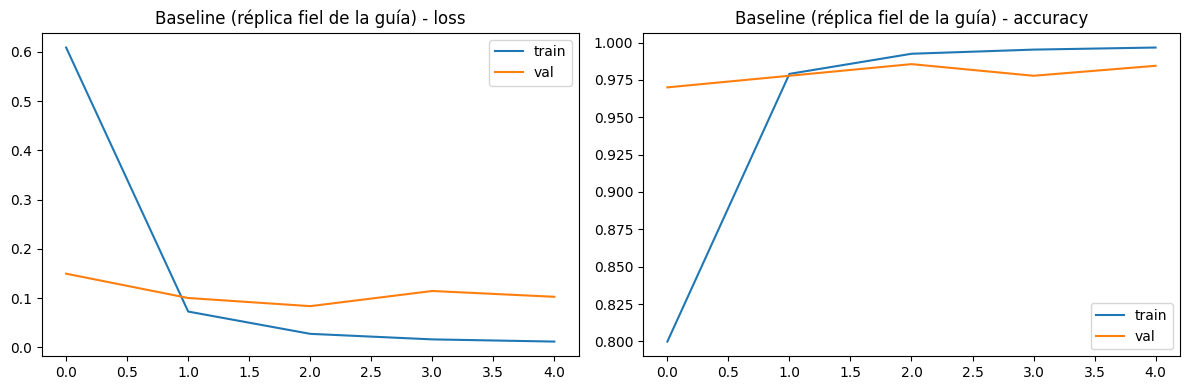


=== Entrenando: Corregido - 1 bloque ===
[Corregido - 1 bloque] Epoch 1/5 - train_loss=1.0598 train_acc=0.7326 val_loss=0.1444 val_acc=0.9633 (13.5s)
[Corregido - 1 bloque] Epoch 2/5 - train_loss=0.0955 train_acc=0.9743 val_loss=0.0657 val_acc=0.9800 (13.4s)
[Corregido - 1 bloque] Epoch 3/5 - train_loss=0.0403 train_acc=0.9878 val_loss=0.0569 val_acc=0.9833 (13.2s)
[Corregido - 1 bloque] Epoch 4/5 - train_loss=0.0207 train_acc=0.9947 val_loss=0.0487 val_acc=0.9867 (13.3s)
[Corregido - 1 bloque] Epoch 5/5 - train_loss=0.0094 train_acc=0.9981 val_loss=0.0550 val_acc=0.9856 (13.1s)


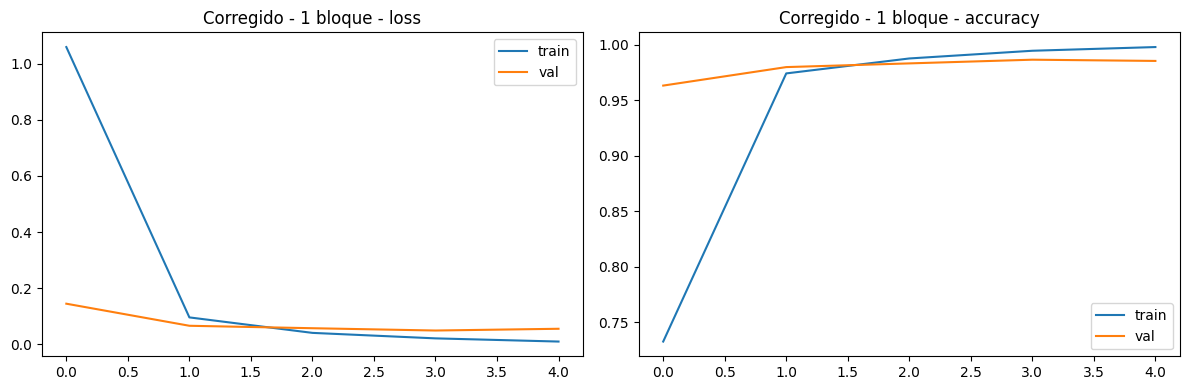


=== Entrenando: Corregido - 3 bloques (Sinusoid) ===
[Corregido - 3 bloques (Sinusoid)] Epoch 1/5 - train_loss=0.8513 train_acc=0.7697 val_loss=0.1115 val_acc=0.9644 (25.8s)
[Corregido - 3 bloques (Sinusoid)] Epoch 2/5 - train_loss=0.0693 train_acc=0.9814 val_loss=0.0542 val_acc=0.9844 (25.6s)
[Corregido - 3 bloques (Sinusoid)] Epoch 3/5 - train_loss=0.0270 train_acc=0.9918 val_loss=0.0515 val_acc=0.9844 (25.7s)
[Corregido - 3 bloques (Sinusoid)] Epoch 4/5 - train_loss=0.0131 train_acc=0.9964 val_loss=0.0655 val_acc=0.9833 (25.6s)
[Corregido - 3 bloques (Sinusoid)] Epoch 5/5 - train_loss=0.0057 train_acc=0.9983 val_loss=0.0384 val_acc=0.9900 (25.6s)


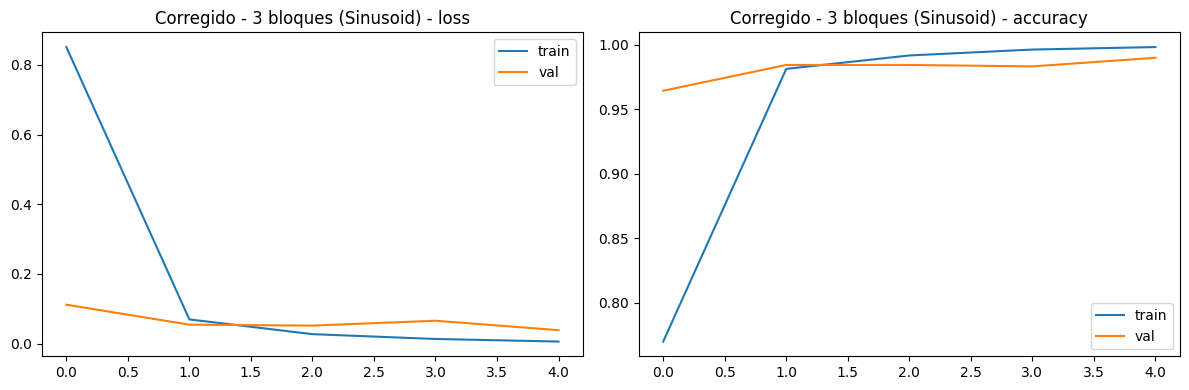


=== Entrenando: Corregido - 3 bloques (Learnable PE) ===
[Corregido - 3 bloques (Learnable PE)] Epoch 1/5 - train_loss=0.9566 train_acc=0.7396 val_loss=0.1801 val_acc=0.9456 (26.0s)
[Corregido - 3 bloques (Learnable PE)] Epoch 2/5 - train_loss=0.1049 train_acc=0.9668 val_loss=0.0859 val_acc=0.9744 (25.6s)
[Corregido - 3 bloques (Learnable PE)] Epoch 3/5 - train_loss=0.0435 train_acc=0.9878 val_loss=0.0864 val_acc=0.9711 (25.6s)
[Corregido - 3 bloques (Learnable PE)] Epoch 4/5 - train_loss=0.0208 train_acc=0.9926 val_loss=0.0586 val_acc=0.9833 (31.2s)
[Corregido - 3 bloques (Learnable PE)] Epoch 5/5 - train_loss=0.0104 train_acc=0.9965 val_loss=0.0604 val_acc=0.9867 (25.8s)


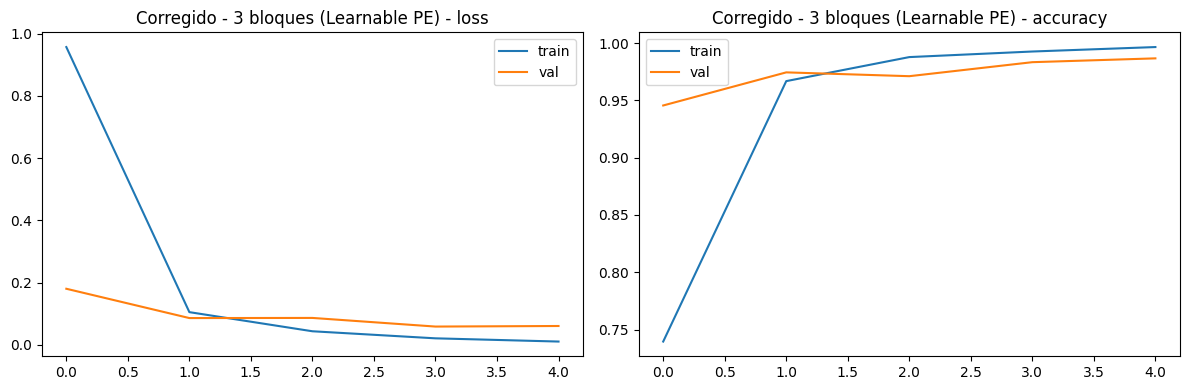

In [ ]:
resultados = {}
modelos_entrenados = {}

for nombre, cfg in modelos_config.items():
    print(f"\n=== Entrenando: {nombre} ===")
    modelo = build_model(cfg)
    modelo_entrenado, historia = train_model(
        modelo, train_loader, val_loader,
        class_weights=class_weights,
        num_epochs=CONFIG['num_epochs'],
        patience=CONFIG['patience'],
        model_name=nombre,
    )
    modelos_entrenados[nombre] = modelo_entrenado
    resultados[nombre] = {'history': historia}
    plot_history(historia, nombre)


Las cuatro variantes convergen rápido: para la segunda época ya están por encima de 96% de exactitud en validación, y para la quinta época el accuracy de entrenamiento está prácticamente en 1.0 en todos los casos. Ahí se nota algo de sobreajuste, porque mientras la pérdida de entrenamiento sigue bajando hasta valores muy cercanos a cero, la pérdida de validación deja de mejorar y en algunos modelos sube un poco entre la tercera y la cuarta época, antes de volver a bajar en la quinta.

El modelo de tres bloques con codificación sinusoidal fue el único que siguió bajando su pérdida de validación hasta la última época sin subir en ningún punto, lo que sugiere que ese modelo en particular todavía tenía margen para mejorar más si se le hubieran dado más épocas.

## 9. Evaluación en el conjunto de prueba


=== Baseline (réplica fiel de la guía) ===
Accuracy: 0.9867 | F1-macro: 0.9840
              precision    recall  f1-score   support

     ACCOUNT       0.98      1.00      0.99       194
      CANCEL       1.00      0.93      0.96        28
     CONTACT       0.97      0.98      0.98        63
    DELIVERY       0.99      0.99      0.99        77
    FEEDBACK       0.99      0.93      0.96        75
     INVOICE       1.00      1.00      1.00        61
       ORDER       0.98      0.99      0.99       122
     PAYMENT       1.00      0.99      0.99        74
      REFUND       0.99      1.00      1.00       103
    SHIPPING       0.99      0.99      0.99        71
SUBSCRIPTION       0.97      1.00      0.98        32

    accuracy                           0.99       900
   macro avg       0.99      0.98      0.98       900
weighted avg       0.99      0.99      0.99       900



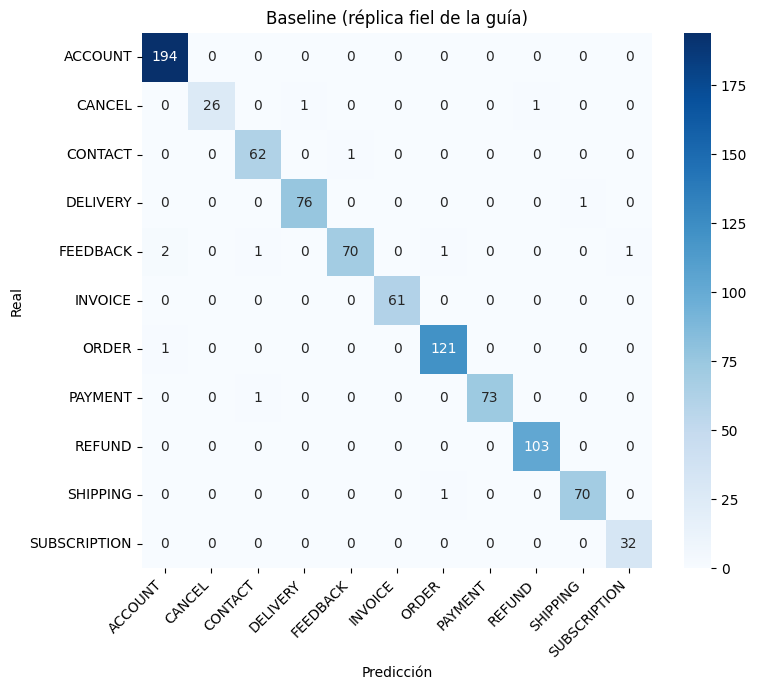


=== Corregido - 1 bloque ===
Accuracy: 0.9867 | F1-macro: 0.9828
              precision    recall  f1-score   support

     ACCOUNT       1.00      0.98      0.99       194
      CANCEL       0.96      0.93      0.95        28
     CONTACT       0.97      0.98      0.98        63
    DELIVERY       0.97      0.99      0.98        77
    FEEDBACK       0.94      0.99      0.96        75
     INVOICE       1.00      1.00      1.00        61
       ORDER       0.99      0.99      0.99       122
     PAYMENT       1.00      0.99      0.99        74
      REFUND       1.00      1.00      1.00       103
    SHIPPING       0.99      0.99      0.99        71
SUBSCRIPTION       1.00      0.97      0.98        32

    accuracy                           0.99       900
   macro avg       0.98      0.98      0.98       900
weighted avg       0.99      0.99      0.99       900



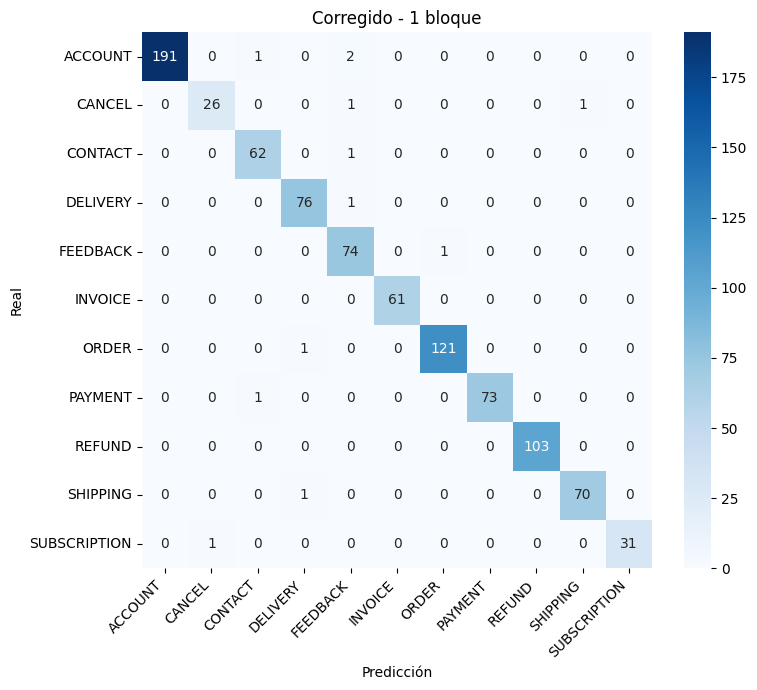


=== Corregido - 3 bloques (Sinusoid) ===
Accuracy: 0.9911 | F1-macro: 0.9877
              precision    recall  f1-score   support

     ACCOUNT       0.99      1.00      1.00       194
      CANCEL       0.93      0.96      0.95        28
     CONTACT       0.98      0.98      0.98        63
    DELIVERY       0.96      1.00      0.98        77
    FEEDBACK       0.99      0.97      0.98        75
     INVOICE       1.00      1.00      1.00        61
       ORDER       1.00      0.99      1.00       122
     PAYMENT       1.00      0.99      0.99        74
      REFUND       1.00      1.00      1.00       103
    SHIPPING       1.00      0.97      0.99        71
SUBSCRIPTION       1.00      1.00      1.00        32

    accuracy                           0.99       900
   macro avg       0.99      0.99      0.99       900
weighted avg       0.99      0.99      0.99       900



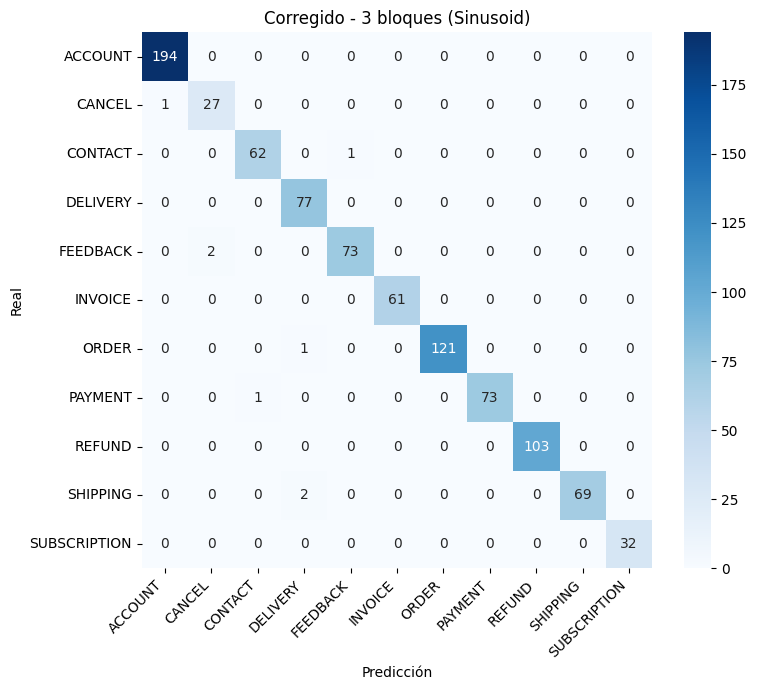


=== Corregido - 3 bloques (Learnable PE) ===
Accuracy: 0.9856 | F1-macro: 0.9838
              precision    recall  f1-score   support

     ACCOUNT       0.98      0.99      0.99       194
      CANCEL       0.93      0.96      0.95        28
     CONTACT       0.98      1.00      0.99        63
    DELIVERY       1.00      0.96      0.98        77
    FEEDBACK       0.96      0.97      0.97        75
     INVOICE       0.98      1.00      0.99        61
       ORDER       0.99      0.97      0.98       122
     PAYMENT       1.00      0.99      0.99        74
      REFUND       0.99      1.00      1.00       103
    SHIPPING       0.99      0.99      0.99        71
SUBSCRIPTION       1.00      1.00      1.00        32

    accuracy                           0.99       900
   macro avg       0.98      0.98      0.98       900
weighted avg       0.99      0.99      0.99       900



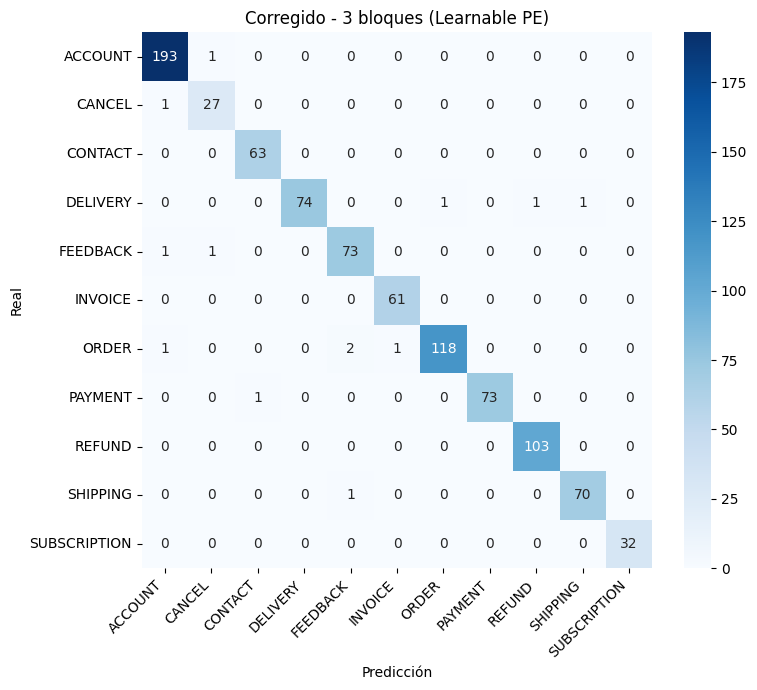

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            y = batch['y'].to(DEVICE)
            logits = model(x, mask)
            preds = logits.argmax(dim=1)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return np.array(y_true), np.array(y_pred)


def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


class_names = [ID_TO_CLASS[i] for i in range(NUM_CLASSES)]

for nombre, modelo in modelos_entrenados.items():
    y_true, y_pred = evaluate_model(modelo, test_loader)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    resultados[nombre]['accuracy'] = acc
    resultados[nombre]['f1_macro'] = f1_macro
    resultados[nombre]['y_true'] = y_true
    resultados[nombre]['y_pred'] = y_pred

    print(f"\n=== {nombre} ===")
    print(f"Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    plot_confusion(y_true, y_pred, class_names, nombre)


### Comparación final

                                 modelo  accuracy  f1_macro  num_parametros
0      Corregido - 3 bloques (Sinusoid)  0.991111  0.987680         1006603
1    Baseline (réplica fiel de la guía)  0.986667  0.984022         2350603
2  Corregido - 3 bloques (Learnable PE)  0.985556  0.983788         1009675
3                  Corregido - 1 bloque  0.986667  0.982797          807435


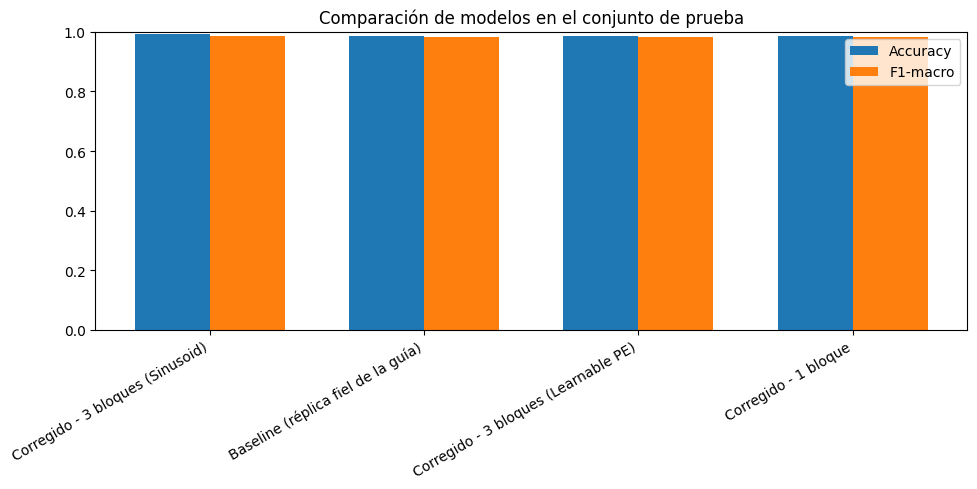


Mejor modelo por F1-macro: Corregido - 3 bloques (Sinusoid)


In [ ]:
comparacion = pd.DataFrame({
    'modelo': list(resultados.keys()),
    'accuracy': [resultados[m]['accuracy'] for m in resultados],
    'f1_macro': [resultados[m]['f1_macro'] for m in resultados],
    'num_parametros': [sum(p.numel() for p in modelos_entrenados[m].parameters()) for m in resultados],
})
comparacion = comparacion.sort_values('f1_macro', ascending=False).reset_index(drop=True)
print(comparacion)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(comparacion))
width = 0.35
ax.bar(x_pos - width/2, comparacion['accuracy'], width, label='Accuracy')
ax.bar(x_pos + width/2, comparacion['f1_macro'], width, label='F1-macro')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparacion['modelo'], rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Comparación de modelos en el conjunto de prueba')
plt.tight_layout()
plt.show()

mejor_nombre = comparacion.iloc[0]['modelo']
mejor_modelo = modelos_entrenados[mejor_nombre]
print(f"\nMejor modelo por F1-macro: {mejor_nombre}")


En este dataset la diferencia de desempeño entre las cuatro variantes terminó siendo pequeña: el F1-macro va de 0.983 en el peor caso hasta 0.988 en el mejor, menos de un punto porcentual de diferencia. El mejor modelo fue el corregido de tres bloques con codificación sinusoidal, con accuracy de 0.991 y F1-macro de 0.988, seguido de cerca por el modelo base que replica los bugs de la guía, con accuracy de 0.987 y F1-macro de 0.984. Es decir que, en cuanto a exactitud, corregir los bugs y apilar bloques ayudó, pero no de forma significativa.

Lo que cambió de forma significativa fue el tamaño del modelo. El modelo base tiene 2.35 millones de parámetros, casi tres veces más que el modelo corregido de un solo bloque, que tiene 807 mil parámetros y obtiene prácticamente la misma exactitud, 0.987 en ambos casos. Esa diferencia viene de haber cambiado el clasificador de Flatten a pooling: el Flatten ataba el tamaño del clasificador al largo máximo de secuencia multiplicado por el tamaño del embedding, mientras que el pooling reduce cualquier secuencia a un solo vector antes de clasificar.

Apilar tres bloques en vez de uno, subió el F1-macro de 0.983 a 0.988, una mejora pequeña pero consistente con la idea de que más profundidad ayuda a capturar relaciones más complejas entre palabras. La codificación posicional aprendida, en cambio, quedó ligeramente por debajo de la sinusoidal, 0.984 contra 0.988, probablemente porque entrenamos con pocas épocas y un subconjunto de 9000 tickets por las limitaciones de CPU, y una codificación que hay que aprender desde cero necesita más datos o más iteraciones para ajustarse bien, mientras que la sinusoidal ya viene con una estructura razonable desde el principio.

Una posible explicación de por qué las diferencias son chicas en general es que este dataset parece bastante fácil de clasificar: muchas categorías tienen palabras casi exclusivas, como factura para INVOICE, reembolso para REFUND o cancelar para CANCEL.

## 10. Visualizando la atención capa por capa

Usamos el modelo corregido de 3 bloques con positional encoding sinusoidal para ver, capa por capa, en qué palabras se fija el modelo al clasificar un ticket real del conjunto de prueba.

Texto: No sé qué debo hacer para cambiar a la cuenta de oro
Categoría real: ACCOUNT | Predicción: ACCOUNT


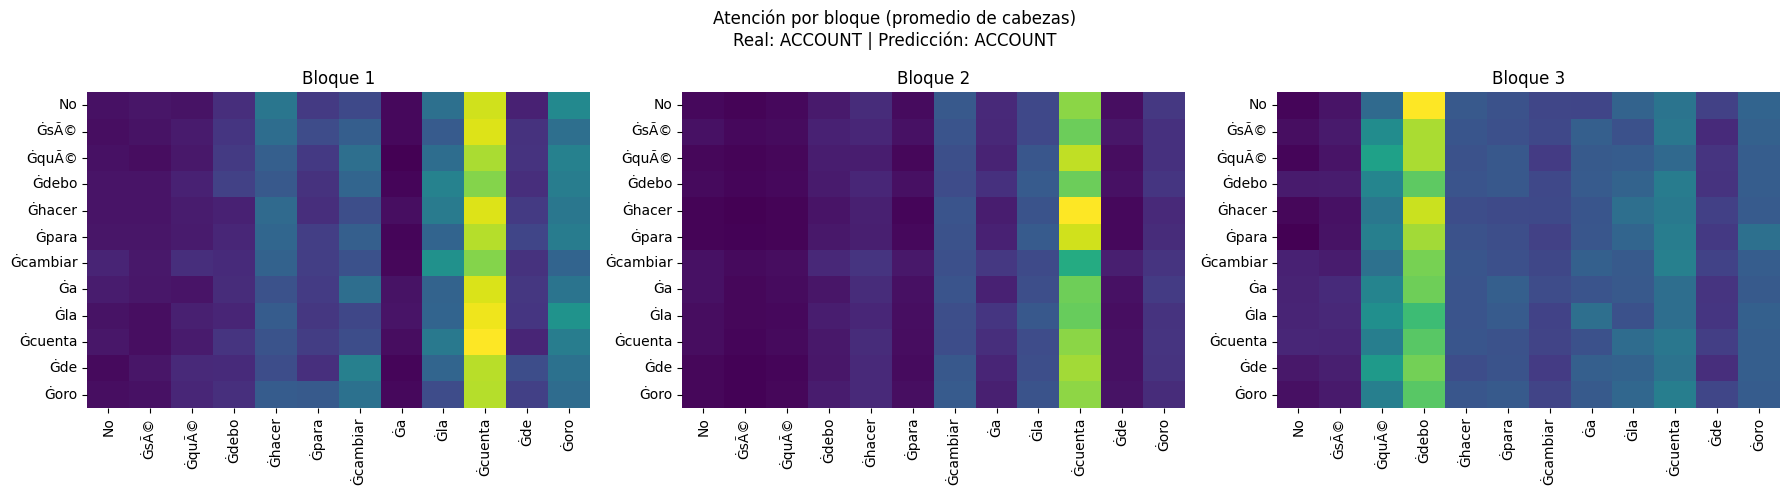

In [ ]:
nombre_para_atencion = 'Corregido - 3 bloques (Sinusoid)'
modelo_atencion = modelos_entrenados[nombre_para_atencion]

idx_ejemplo = test_dataset.indices[0]
idx_full = used_idx[idx_ejemplo]
texto_ejemplo = df.iloc[idx_full]['instruction']
categoria_real = df.iloc[idx_full]['category']

enc = tickets_tokenizer(texto_ejemplo, max_length=CONFIG['max_len'], truncation=True, padding='max_length')
x = torch.tensor([enc['input_ids']]).to(DEVICE)
mask = torch.tensor([enc['attention_mask']]).to(DEVICE)

modelo_atencion.eval()
with torch.no_grad():
    logits, attentions = modelo_atencion(x, mask, return_attention=True)
pred_idx = logits.argmax(dim=1).item()

print(f"Texto: {texto_ejemplo}")
print(f"Categoría real: {categoria_real} | Predicción: {ID_TO_CLASS[pred_idx]}")

tokens = tickets_tokenizer.convert_ids_to_tokens(enc['input_ids'])
n_tokens_reales = int(sum(enc['attention_mask']))

n_blocks = len(attentions)
fig, axes = plt.subplots(1, n_blocks, figsize=(6 * n_blocks, 5))
if n_blocks == 1:
    axes = [axes]
for i, attn in enumerate(attentions):
    attn_avg = attn[0].mean(dim=0).cpu().numpy()
    sns.heatmap(
        attn_avg[:n_tokens_reales, :n_tokens_reales],
        xticklabels=tokens[:n_tokens_reales],
        yticklabels=tokens[:n_tokens_reales],
        cmap='viridis', ax=axes[i], cbar=False,
    )
    axes[i].set_title(f'Bloque {i + 1}')
    axes[i].tick_params(axis='x', rotation=90)
plt.suptitle(f'Atención por bloque (promedio de cabezas)\nReal: {categoria_real} | Predicción: {ID_TO_CLASS[pred_idx]}')
plt.tight_layout()
plt.show()


Con el ejemplo que probamos, el ticket "No sé qué debo hacer para cambiar a la cuenta de oro", clasificado de forma correcta como ACCOUNT, sí hay diferencia entre bloques, pero no en el sentido de que la atención se vuelva más fina o más repartida. En los bloques 1 y 2 casi todas las palabras terminan prestando la mayor parte de su atención a un mismo token, cuenta, que es justamente la palabra más relacionada con la categoría ACCOUNT. En el bloque 3 ese punto de concentración cambia y pasa a la palabra debo, que por sí sola no tiene relación obvia con la categoría.

Esto tiene sentido con lo que vimos en la comparación de modelos: el modelo funciona bien prediciendo la categoría correcta, pero la forma en que reparte la atención no es tan interpretable como uno esperaría en teoría. En la práctica, con un modelo tan chico entrenado con tan pocos datos, la atención tiende a concentrarse sobre uno o dos tokens en vez de repartirse de manera adecuada entre todas las palabras de la oración.

Vale la pena mencionar también que las etiquetas de los tokens en el gráfico salen con caracteres raros, como una q u e seguida de símbolos en vez de qué. Eso es solo un problema de cómo se están decodificando los bytes del tokenizador al mostrar los textos, no afecta en nada el entrenamiento ni las predicciones del modelo.

## 11. Análisis de errores del mejor modelo

In [ ]:
y_true_best = resultados[mejor_nombre]['y_true']
y_pred_best = resultados[mejor_nombre]['y_pred']

test_full_indices = [used_idx[i] for i in test_dataset.indices]
textos_test = [df.iloc[i]['instruction'] for i in test_full_indices]

errores_df = pd.DataFrame({
    'texto': textos_test,
    'categoria_real': [ID_TO_CLASS[i] for i in y_true_best],
    'categoria_predicha': [ID_TO_CLASS[i] for i in y_pred_best],
})
errores_df = errores_df[errores_df['categoria_real'] != errores_df['categoria_predicha']]

print(f"Total de errores: {len(errores_df)} de {len(textos_test)} ({100 * len(errores_df) / len(textos_test):.1f}%)")
errores_df.sample(min(15, len(errores_df)), random_state=SEED)


Total de errores: 8 de 900 (0.9%)


,texto,categoria_real,categoria_predicha
155,presentando una solicitud de asistencia para l...,FEEDBACK,CANCEL
616,con la penalidad de pérdida de tiempo,CANCEL,ACCOUNT
38,¿Puede decirme algo sobre una modificación de ...,SHIPPING,DELIVERY
853,¿Puedo modificar la compra __ hwPLACEHOLDER_0__?,ORDER,DELIVERY
303,¿Qué tengo que hacer para contratar a un asist...,CONTACT,FEEDBACK
488,El archivo de reclamos de los clientes.,FEEDBACK,CANCEL
464,No puedo enviar un correo electrónico de entre...,SHIPPING,DELIVERY
639,Resolver problemas con apyment,PAYMENT,CONTACT


El mejor modelo se equivocó en solo 8 de los 900 tickets de prueba, menos del 1 por ciento. Mirando esos ocho casos, hay un patrón que se repite: dos de los errores confunden SHIPPING con DELIVERY, una pregunta sobre modificar una dirección de envío y otra sobre no poder enviar un correo de confirmación, lo cual tiene sentido porque son categorías que hablan de cosas parecidas, el envío y la entrega de un pedido, y en textos tan cortos a veces no alcanza la información para distinguir cuál de las dos aplica.

También hay dos casos donde FEEDBACK se confunde con CANCEL, una solicitud de asistencia y un comentario sobre un archivo de reclamos, que son textos ambiguos incluso para una persona, porque un reclamo puede terminar siendo tanto una queja como el inicio de una cancelación.

Uno de los errores fue interesante por otra razón: el ticket dice Resolver problemas con apyment, con una palabra mal escrita en vez de payment, y el modelo lo clasificó como CONTACT en vez de PAYMENT. Es razonable pensar que, al no reconocer bien esa palabra clave mal escrita, el modelo se quedó sin la pista más fuerte para ubicar el ticket en la categoría correcta.

Otro caso muestra más bien un problema del dataset que del modelo: uno de los textos de prueba tiene un resto de plantilla sin reemplazar, algo como un guion bajo seguido de un marcador de posición en vez de un número de pedido real, lo que sugiere que el dataset original trae algunos tickets generados de forma automática que no se limpiaron del todo.

En general, los ocho errores parecen razonables: son casos donde incluso una persona dudaría entre dos categorías, no errores que se vean arbitrarios o injustificados.

## 12. Demo clasificador de tickets

Texto: Llevo dos semanas esperando el reembolso de mi pedido y nadie me responde
  REFUND: 73.9%
  DELIVERY: 20.9%
  ACCOUNT: 1.8%


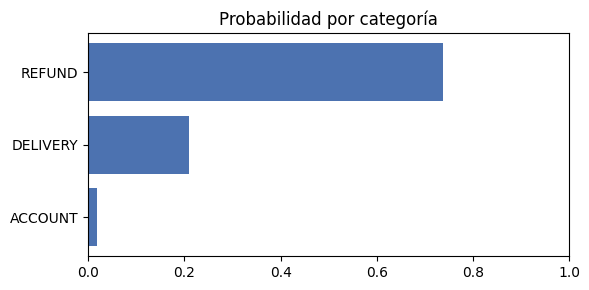


Texto: Quiero cambiar la dirección de envío antes de que despachen mi compra
  SHIPPING: 99.9%
  ORDER: 0.0%
  FEEDBACK: 0.0%


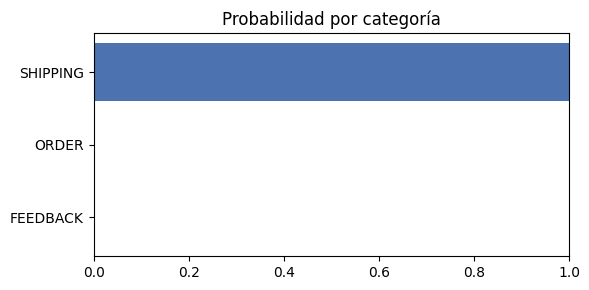


Texto: No puedo iniciar sesión en mi cuenta, dice que la contraseña es incorrecta
  ACCOUNT: 99.9%
  SUBSCRIPTION: 0.1%
  DELIVERY: 0.0%


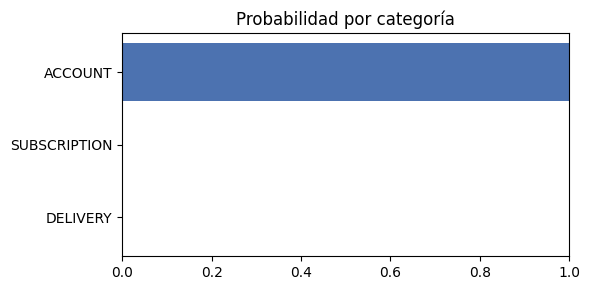


Texto: Me cobraron dos veces la misma factura este mes
  INVOICE: 100.0%
  REFUND: 0.0%
  PAYMENT: 0.0%


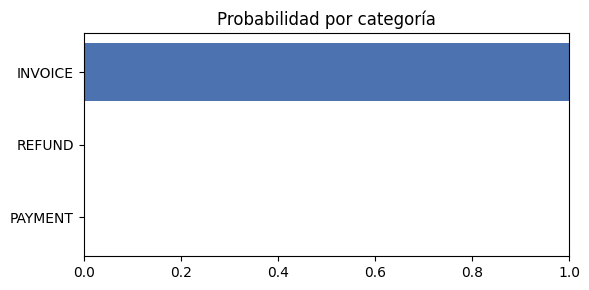

In [ ]:
def predecir_categoria(texto, modelo=None, top_k=3):
    if modelo is None:
        modelo = mejor_modelo
    modelo.eval()
    enc = tickets_tokenizer(texto, max_length=CONFIG['max_len'], truncation=True, padding='max_length')
    x = torch.tensor([enc['input_ids']]).to(DEVICE)
    mask = torch.tensor([enc['attention_mask']]).to(DEVICE)
    with torch.no_grad():
        logits = modelo(x, mask)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()

    orden = np.argsort(probs)[::-1][:top_k]
    print(f"Texto: {texto}")
    for i in orden:
        print(f"  {ID_TO_CLASS[i]}: {probs[i] * 100:.1f}%")

    plt.figure(figsize=(6, 3))
    plt.barh([ID_TO_CLASS[i] for i in orden][::-1], probs[orden][::-1], color='#4C72B0')
    plt.xlim(0, 1)
    plt.title('Probabilidad por categoría')
    plt.tight_layout()
    plt.show()
    return ID_TO_CLASS[orden[0]]


ejemplos_propios = [
    "Llevo dos semanas esperando el reembolso de mi pedido y nadie me responde",
    "Quiero cambiar la dirección de envío antes de que despachen mi compra",
    "No puedo iniciar sesión en mi cuenta, dice que la contraseña es incorrecta",
    "Me cobraron dos veces la misma factura este mes",
]

for texto in ejemplos_propios:
    predecir_categoria(texto)
    print()


## 13. Conclusiones

Comparado con la arquitectura de la guía, corregir los bugs ayudó, aunque no tanto en la exactitud final, que ya era alta incluso con los bugs, sino en la eficiencia del modelo. El clasificador corregido de un solo bloque llega prácticamente al mismo desempeño que el modelo base, 0.987 de exactitud en ambos, con menos de la tercera parte de los parámetros, simplemente por haber cambiado el Flatten por un pooling. Apilar tres bloques en vez de uno dio una mejora adicional pequeña pero real en el F1-macro, de 0.983 a 0.988, y terminó siendo, junto con la corrección del clasificador, el cambio que más aportó. Cambiar la codificación posicional sinusoidal por una aprendida no ayudó en este caso, quedó un poco por debajo, probablemente porque entrenamos pocas épocas sobre un subconjunto de 9000 tickets por las limitaciones de correr en CPU, y una codificación aprendida necesita más datos o más tiempo de entrenamiento para ajustarse bien.

El manejo del desbalance con pesos de clase parece haber funcionado. Aunque la categoría más frecuente, ACCOUNT, tiene más de seis veces los tickets de las categorías más chicas, CANCEL y SUBSCRIPTION, el reporte de clasificación no muestra que el modelo ignore las categorías pequeñas, y el F1-macro, que pesa todas las categorías por igual, queda muy cerca del accuracy en todos los modelos.

Las limitaciones más importantes de este trabajo tienen que ver con la escala. Entrenamos con un vocabulario de apenas 5250 tokens y con un subconjunto de 9000 tickets de los 24184 disponibles, porque el entrenamiento se hizo en CPU. No sabemos qué tanto cambiarían los resultados, sobre todo la comparación entre codificación sinusoidal y aprendida, si se entrenara con el dataset completo y más épocas. Tampoco usamos la etiqueta de intent, que es más fina que category y probablemente sea un problema bastante más difícil, donde sí sería de esperar que las correcciones a la arquitectura pesen más. El análisis de errores también dejó ver que el propio dataset tiene algunos tickets con restos de plantillas sin limpiar, lo cual es un límite de los datos y no del modelo.

## Referencias

- Dataset: [`Faramir/Bitext-customer-support-llm-chatbot-training-dataset-spanish`](https://huggingface.co/datasets/Faramir/Bitext-customer-support-llm-chatbot-training-dataset-spanish), traducción al español del dataset original de Bitext para entrenamiento de chatbots de soporte al cliente.
- [Attention Is All You Need](https://arxiv.org/abs/1706.03762) (Vaswani et al., 2017) — arquitectura Transformer original, incluyendo las conexiones residuales alrededor de cada sub-capa.
- Notebook guía del curso: `1-transformers-from-scratch.ipynb` (Sesión 2).
